<a href="https://colab.research.google.com/github/Shivam0400/Accident-Predictor/blob/main/Colab_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Accuracy-Driven Learning on Real-World Accident Dataset

This notebook contains the foundation for our deep learning and machine learning pipeline, designed specifically for Google Colab.

## 1. Environment Setup & Data Ingestion

In [ ]:
# Install necessary high-performance libraries included in our plan
!pip install -q xgboost lightgbm optuna shap imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.0 MB/s eta 0:00:00
Libraries loaded successfully!


### Load Data from Google Drive (Recommended for Large Datasets)
Since you already have the CSV file, upload it to your Google Drive in a folder. Then run this cell to mount your Drive and load the CSV.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# TODO: Change this to the actual path where you uploaded your CSV in Google Drive
# For example, if you uploaded it directly to your MyDrive, it might be '/content/drive/MyDrive/accidents.csv'
csv_file_path = '/content/drive/MyDrive/indian_roads_dataset.csv'

print(f"Reading data from {csv_file_path}...")
df = pd.read_csv(csv_file_path)

print("Data loaded successfully! Here are the first 5 rows:")
display(df.head())
print("\nDataset Info:")
display(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading data from /content/drive/MyDrive/indian_roads_dataset.csv...
Data loaded successfully! Here are the first 5 rows:


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic

None

## 2. Advanced Feature Engineering
Extracting temporal, spatial, and contextual insights to maximize predictive accuracy.

In [ ]:
# =========================
# 🚀 FINAL HYBRID MODEL (WEATHER + TRAFFIC + XGBOOST)
# =========================

# 📦 Imports
import pandas as pd
import numpy as np
import requests
from time import sleep
import xgboost as xgb
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# =========================
# 📂 LOAD DATA
# =========================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/indian_roads_dataset.csv')
print("✅ Data Loaded")

# =========================
# 🧹 CLEANING
# =========================
print("\nMissing Values:\n", df.isnull().sum())

df.drop_duplicates(inplace=True)

# Fix numeric
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df['hour'] = df['hour'].fillna(df['hour'].median())

df['accident_severity'] = pd.to_numeric(df['accident_severity'], errors='coerce')
df['accident_severity'] = df['accident_severity'].fillna(df['accident_severity'].median())

# Fill categorical
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("✅ Cleaning Done")

# =========================
# ⚙️ FEATURE ENGINEERING
# =========================
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_morning_rush'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int)
df['is_evening_rush'] = ((df['hour'] >= 16) & (df['hour'] <= 18)).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

print("✅ Feature Engineering Done")

# =========================
# 🌦️ WEATHER API
# =========================
API_KEY = "3fa3df041e9aab6e438da9e9683c49ba"

def get_weather(lat, lon):
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}"
        res = requests.get(url).json()
        return {
            "temp": res["main"]["temp"],
            "humidity": res["main"]["humidity"],
            "weather_main": res["weather"][0]["main"]
        }
    except:
        return {"temp": None, "humidity": None, "weather_main": None}

print("🌦️ Fetching weather (this may take time)...")

weather_data = []

for i, row in df.iterrows():
    lat = row['latitude']   # change if needed
    lon = row['longitude']

    weather_data.append(get_weather(lat, lon))

    if i % 50 == 0:
        print(f"Processed {i}")
    sleep(1)

weather_df = pd.DataFrame(weather_data)
df = pd.concat([df.reset_index(drop=True), weather_df], axis=1)

# Fill missing
df['temp'] = df['temp'].fillna(df['temp'].median())
df['humidity'] = df['humidity'].fillna(df['humidity'].median())
df['weather_main'] = df['weather_main'].fillna("Clear")

print("✅ Weather Added")

# =========================
# 🚗 TRAFFIC + ROAD
# =========================
df['traffic_density'] = 0

df.loc[df['hour'].between(7, 9), 'traffic_density'] = 2
df.loc[df['hour'].between(16, 19), 'traffic_density'] = 2
df.loc[df['hour'].between(10, 15), 'traffic_density'] = 1
df.loc[df['hour'].between(20, 23), 'traffic_density'] = 1

df['road_type'] = "urban"
df.loc[df['traffic_density'] == 2, 'road_type'] = "highway"

print("✅ Traffic Added")

# =========================
# 🔢 ENCODING
# =========================
df = pd.get_dummies(df, columns=['weather_main', 'road_type'], drop_first=True)

# =========================
# 🎯 FEATURES & TARGET
# =========================
cols_to_drop = ['date', 'time', 'accident_id']

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns] + ['accident_severity'], errors='ignore')
y = df['accident_severity']

# Encode target
le = LabelEncoder()
y = le.fit_transform(y)

# One-hot encode all remaining categorical columns in X
X = pd.get_dummies(X, drop_first=True)

# =========================
# 🔀 SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# ⚖️ SMOTE
# =========================
sm = SMOTE()
X_train, y_train = sm.fit_resample(X_train, y_train)

print("✅ Data Ready")

# =========================
# 🤖 MODEL (XGBOOST)
# =========================
model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

print("✅ Model Trained")

# =========================
# 📊 EVALUATION
# =========================
preds = model.predict(X_test)

print("\n🔥 Accuracy:", accuracy_score(y_test, preds))
print("\n", classification_report(y_test, preds))

# =========================
# 📈 FEATURE IMPORTANCE
# =========================
xgb.plot_importance(model)
plt.show()

# =========================
# 🔍 SHAP
# =========================
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# =========================
# 💾 SAVE
# =========================
model.save_model("final_model.json")
joblib.dump(le, "label_encoder.pkl")

print("✅ Model Saved")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Loaded

Missing Values:
 accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64
✅ Cleaning Done
✅ Feature Engineering Done
🌦️ Fetching weather (this may take time)...
Processed 0
Processed 50
Processed 100
Processed 150
Processed 200
Processed 250
Processed 

ValueError: The target 'y' needs to have more than 1 class. Got 1 class instead

## 3. Specific Learning Tasks

### Task A: Accident Severity Prediction (Classification)
Using ensemble learning (XGBoost) for high accuracy classification.

📂 Loading dataset...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset Loaded!

   accident_id        city        state   latitude  longitude        date  \
0            0        Pune  Maharashtra  18.680827  73.930388  2023-10-22   
1            1      Mumbai  Maharashtra  18.817732  72.790846  2023-05-21   
2            2      Mumbai  Maharashtra  19.096889  72.819424  2024-07-10   
3            3  Chandigarh       Punjab  30.787805  76.847507  2025-03-30   
4            4     Chennai   Tamil Nadu  12.965155  80.283313  2024-01-25   

    time  hour day_of_week  is_weekend  ... visibility  temperature  \
0   5:00     5      Sunday           1  ...        low           32   
1   4:00     4      Sunday           1  ...       high           34   
2  13:00    13   Wednesday           0  ...        low           21   
3  11:00    11      Sunday           1  ...        low           30   
4  16:00    1

<Figure size 640x480 with 0 Axes>

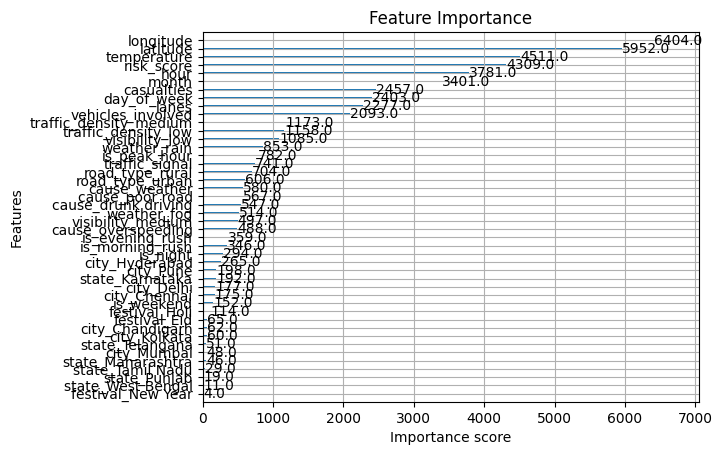


🔍 SHAP Analysis...


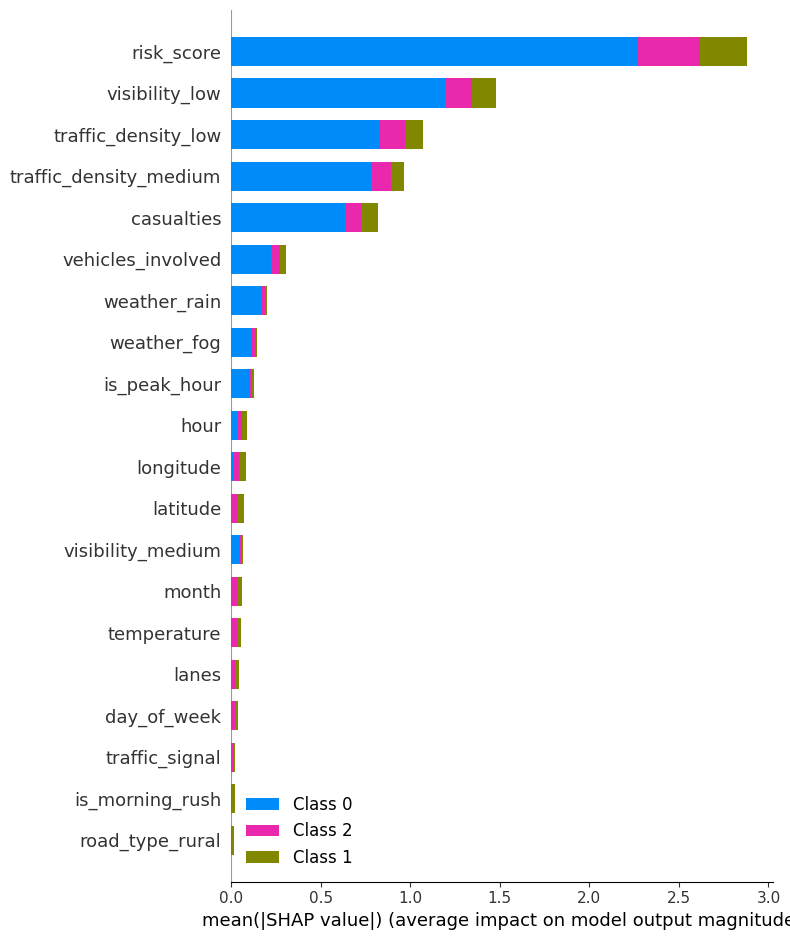


💾 Saving Model...
✅ Model Saved Successfully!


In [ ]:
# =========================
# 🚀 ACCIDENT SEVERITY PREDICTION (FINAL OPTIMIZED)
# =========================

# 📦 Imports
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# =========================
# 📂 LOAD DATA
# =========================
print("📂 Loading dataset...")

from google.colab import drive
drive.mount('/content/drive')

csv_file_path = '/content/drive/MyDrive/indian_roads_dataset.csv'
df = pd.read_csv(csv_file_path)

print("✅ Dataset Loaded!\n")
print(df.head())


# =========================
# 🧹 DATA CLEANING
# =========================
print("\n🧹 Cleaning Data...")

# 👉 REQUIRED LINE 1: Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop duplicates (corrected syntax)
df.drop_duplicates(inplace=True)

print("✅ Cleaning Done!")


# =========================
# ⚙️ FEATURE ENGINEERING
# =========================
print("\n⚙️ Feature Engineering...")

df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Fix: Avoid FutureWarning by direct assignment instead of inplace=True
df['hour'] = df['hour'].fillna(df['hour'].median())

df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['is_morning_rush'] = df['hour'].apply(lambda x: 1 if 7 <= x <= 9 else 0)
df['is_evening_rush'] = df['hour'].apply(lambda x: 1 if 16 <= x <= 18 else 0)
df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 22 or x <= 5 else 0)

print("✅ Feature Engineering Done!")


# =========================
# 🎯 FEATURE & TARGET SPLIT
# =========================
print("\n🎯 Preparing Features & Target...")

cols_to_drop = ['date', 'time', 'accident_id']

# 👉 REQUIRED LINE 2 (placed correctly BEFORE encoding)
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns] + ['accident_severity'], errors='ignore')
y = df['accident_severity']

# Encode target variable 'accident_severity' into numerical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Fix labels if needed
# This check is now valid as 'y' is numerical
if y.min() > 0:
    y = y - y.min()

print("✅ Feature & Target Ready!")


# =========================
# 🔢 ENCODING
# =========================
print("\n🔢 Applying One-Hot Encoding...")

# 👉 REQUIRED LINE 3 (correct place AFTER X creation)
df = pd.get_dummies(df, columns=['weather_main', 'road_type'], drop_first=True)

print("✅ Encoding Done!")

cols_to_drop = ['date', 'time', 'accident_id']

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns] + ['accident_severity'], errors='ignore')
y = df['accident_severity']
# =========================
# 🔀 TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data Split Complete!")


# =========================
# 🤖 MODEL TRAINING
# =========================
print("\n🚀 Training Model...")

model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)

print("✅ Model Trained!")


# =========================
# 📊 EVALUATION
# =========================
print("\n📊 Evaluating Model...")

preds = model.predict(X_test)

print(f"\n✅ Accuracy: {accuracy_score(y_test, preds):.4f}")
print("\n📄 Classification Report:\n")
print(classification_report(y_test, preds))


# =========================
# 📈 FEATURE IMPORTANCE
# =========================
print("\n📈 Feature Importance...")

plt.figure()
xgb.plot_importance(model)
plt.title("Feature Importance")
plt.show()


# =========================
# 🔍 SHAP EXPLAINABILITY
# =========================
print("\n🔍 SHAP Analysis...")

explainer = shap.Explainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


# =========================
# 💾 SAVE MODEL
# =========================
print("\n💾 Saving Model...")

model.save_model("accident_severity_model.json")

print("✅ Model Saved Successfully!")

### Task B: Interpetability (SHAP values)
Making the AI robust and interpretable as requested in the problem statement.

Calculating SHAP values for model interpretability...


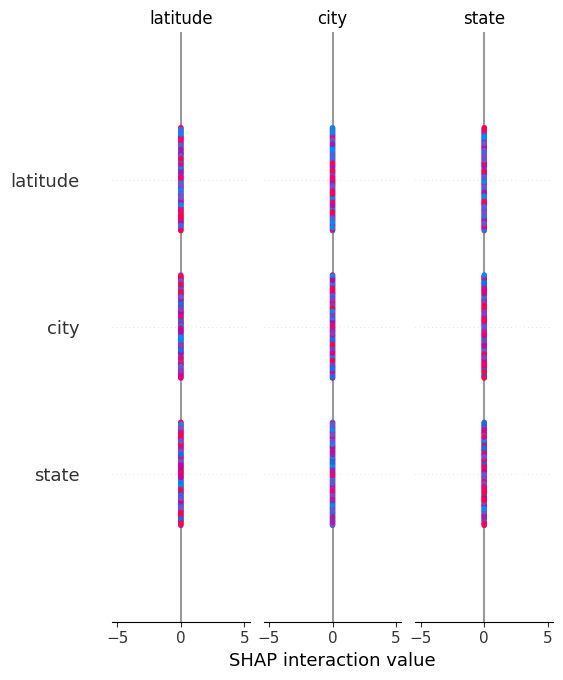

In [ ]:
import shap

def explain_model(model, X_train):
    print("Calculating SHAP values for model interpretability...")
    explainer = shap.TreeExplainer(model)
    # Use a small subset (100) for fast rendering in Colab
    shap_values = explainer.shap_values(X_train[:100])

    shap.summary_plot(shap_values, X_train[:100])

try:
    explain_model(severity_model, X_train_sample)
except NameError:
    print("Model was not trained successfully above. Fix errors first!")

Starting Geographic Hotspot Detection...
Detected 107 High-Risk Danger Hotspots!


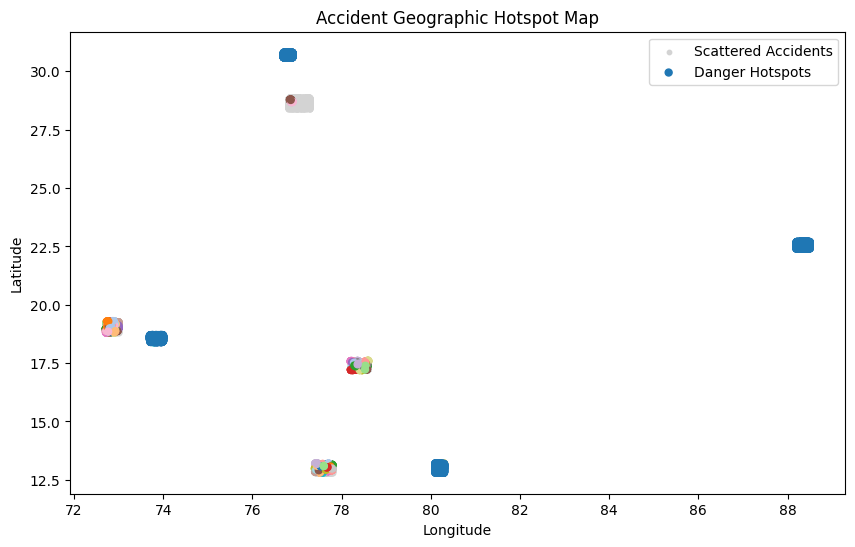

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

print("Starting Geographic Hotspot Detection...")
# Extracting Geographic Coordinates
coords = df[['latitude', 'longitude']].dropna().values

# DBSCAN Clustering (This groups accidents that happen within a ~1.5km radius of each other)
kms_per_radian = 6371.0088
epsilon = 1.5 / kms_per_radian

db = DBSCAN(eps=epsilon, min_samples=15, algorithm='ball_tree', metric='haversine')
df['hotspot_cluster'] = db.fit_predict(np.radians(coords))

# Any cluster ID that is not -1 is considered a high-risk Hotspot!
hotspots = df[df['hotspot_cluster'] != -1]
print(f"Detected {len(set(hotspots['hotspot_cluster']))} High-Risk Danger Hotspots!")

# Plotting the hotspots
plt.figure(figsize=(10,6))
plt.scatter(df['longitude'], df['latitude'], c='lightgray', s=10, label='Scattered Accidents')
plt.scatter(hotspots['longitude'], hotspots['latitude'], c=hotspots['hotspot_cluster'], cmap='tab20', s=25, label='Danger Hotspots')
plt.title("Accident Geographic Hotspot Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Loaded

Missing Values:
 accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64
Before SMOTE:
 2    11025
1     5988
0     2987
Name: count, dtype: int64
After SMOTE:
 0    11025
1    11025
2    11025
Name: count, dtype: int64
Fitting 3 folds for each of 10 

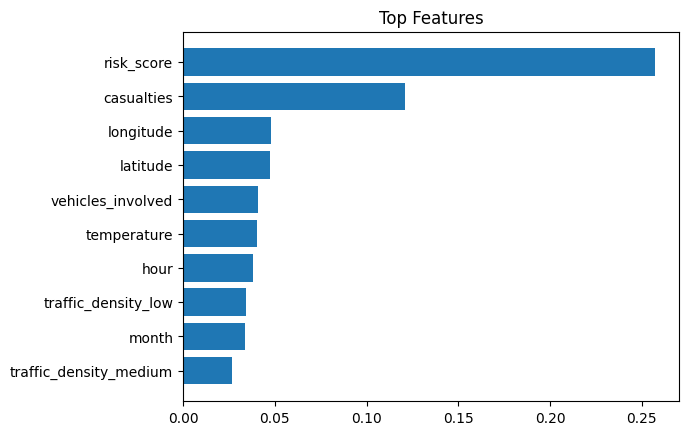

✅ Model Saved!


In [ ]:
# =========================
# 🚀 ADVANCED RANDOM FOREST (HIGH ACCURACY)
# =========================

# 📦 Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# =========================
# 📂 LOAD DATA
# =========================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/indian_roads_dataset.csv')

print("✅ Data Loaded")


# =========================
# 🧹 CLEANING
# =========================
print("\nMissing Values:\n", df.isnull().sum())

df.drop_duplicates(inplace=True)

# Convert numeric columns
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df['hour'] = df['hour'].fillna(df['hour'].median())

# Removed incorrect conversion for accident_severity. It should be label encoded.
# df['accident_severity'] = pd.to_numeric(df['accident_severity'], errors='coerce')
# df['accident_severity'] = df['accident_severity'].fillna(df['accident_severity'].median())


# =========================
# ⚙️ FEATURE ENGINEERING
# =========================
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

df['is_morning_rush'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int)
df['is_evening_rush'] = ((df['hour'] >= 16) & (df['hour'] <= 18)).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)

# 🔥 NEW FEATURES (IMPORTANT)
df['rush_hour'] = df['is_morning_rush'] + df['is_evening_rush']
df['weekend_night'] = df['is_weekend'] * df['is_night']


# =========================
# 🎯 FEATURES & TARGET
# =========================
cols_to_drop = ['date', 'time', 'accident_id']

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns] + ['accident_severity'], errors='ignore')
y = df['accident_severity']

# Encode target variable 'accident_severity' into numerical labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

if y.min() > 0:
    y = y - y.min()


# =========================
# 🔢 ENCODING
# =========================
X = pd.get_dummies(X, drop_first=True)


# =========================
# ⚖️ HANDLE IMBALANCE (SMOTE 🔥)
# =========================
print("Before SMOTE:\n", pd.Series(y).value_counts())

smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)

print("After SMOTE:\n", pd.Series(y).value_counts())


# =========================
# 🔀 SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# 🔍 HYPERPARAMETER TUNING
# =========================
param_dist = {
    'n_estimators': [300, 500, 700],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

model = search.best_estimator_

print("Best Parameters:", search.best_params_)


# =========================
# 📊 EVALUATION
# =========================
preds = model.predict(X_test)

print("\n✅ Accuracy:", accuracy_score(y_test, preds))
print("\nClassification Report:\n", classification_report(y_test, preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))


# =========================
# 📈 FEATURE IMPORTANCE
# =========================
importances = model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top Features")
plt.show()


# =========================
# 💾 SAVE MODEL
# =========================
joblib.dump(model, "rf_high_accuracy.pkl")

print("✅ Model Saved!")

In [ ]:
# =========================
# 🚀 MAX ACCURACY PIPELINE (FINAL)
# =========================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder # Import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_selection import SelectFromModel

from imblearn.over_sampling import SMOTE
import xgboost as xgb

# =========================
# 📂 LOAD DATA
# =========================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/indian_roads_dataset.csv')

print("Loaded Data")


# =========================
# 🧹 CLEANING
# =========================
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

# Numeric fixes
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df['hour'] = df['hour'].fillna(df['hour'].median())

# FIX: Removed incorrect numeric conversion and fillna for accident_severity.
# It's a categorical target and should be label encoded later.
# df['accident_severity'] = pd.to_numeric(df['accident_severity'], errors='coerce')
# df['accident_severity'] = df['accident_severity'].fillna(df['accident_severity'].median())

# Fill categorical properly
# This loop should ideally come after initial target variable handling if it's not meant to be filled here.
# For now, let's assume 'festival' is the primary object column needing filling.
for col in df.select_dtypes(include='object').columns:
    if col != 'accident_severity': # Exclude accident_severity from this generic fillna
        df[col] = df[col].fillna(df[col].mode()[0])


# =========================
# ⚙️ FEATURE ENGINEERING
# =========================
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
df['rush_hour'] = ((df['hour'].between(7,9)) | (df['hour'].between(16,18))).astype(int)

# Drop high noise columns if exist
df.drop(columns=['date','time'], errors='ignore', inplace=True)


# =========================
# 🎯 SPLIT
# =========================
X = df.drop(columns=['accident_severity'], errors='ignore')

# FIX: Use LabelEncoder for the target variable 'accident_severity'
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['accident_severity'])

# Removed the `if y.min() > 0: y = y - y.min()` block as LabelEncoder typically starts from 0.

# Encoding
X = pd.get_dummies(X, drop_first=True)


# =========================
# 🔀 TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# =========================
# ⚖️ SMOTE (AFTER SPLIT)
# =========================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


# =========================
# ⚖️ SCALING
# =========================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =========================
# 🎯 FEATURE SELECTION (STRONG)
# =========================
selector_model = RandomForestClassifier(n_estimators=200)
selector_model.fit(X_train, y_train)

selector = SelectFromModel(selector_model, threshold="median")
X_train = selector.transform(X_train)
X_test = selector.transform(X_test)


# =========================
# 🔥 MODELS
# =========================

# Logistic
lr = LogisticRegression(max_iter=2000)

# Random Forest (tuned)
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

# XGBoost (strongest)
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)


# =========================
# 🧠 STACKING (BEST)
# =========================
stack = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', xgb_model)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack.fit(X_train, y_train)


# =========================
# 📊 EVALUATION
# =========================
preds = stack.predict(X_test)

print("\n🔥 FINAL ACCURACY:", accuracy_score(y_test, preds))
print("\n", classification_report(y_test, preds))


# =========================
# 💾 SAVE
# =========================
joblib.dump(stack, "final_best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Model Saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded Data
accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

🔥 FINAL ACCURACY: 0.66475

               precision    recall  f1-score   support

           0       0.99      1.00      1.00       597
           1       0.36      0.16      0.22      1198
      

In [ ]:
# =========================
# 🚀 HYBRID MODEL (KMEANS + ENSEMBLE)
# =========================

import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder # Import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from imblearn.over_sampling import SMOTE
import xgboost as xgb

# =========================
# 📂 LOAD DATA
# =========================
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/indian_roads_dataset.csv')

print("✅ Data Loaded")


# =========================
# 🧹 CLEANING
# =========================
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df['hour'] = df['hour'].fillna(df['hour'].median())

# FIX: Removed incorrect numeric conversion and fillna for accident_severity.
# It's a categorical target and should be label encoded later.
# df['accident_severity'] = pd.to_numeric(df['accident_severity'], errors='coerce')
# df['accident_severity'] = df['accident_severity'].fillna(df['accident_severity'].median())

# Fill categorical columns. Exclude 'accident_severity' from this general fillna
for col in df.select_dtypes(include='object').columns:
    if col != 'accident_severity':
        df[col] = df[col].fillna(df[col].mode()[0])


# =========================
# ⚙️ FEATURE ENGINEERING
# =========================
df['date'] = pd.to_datetime(df['date'], errors='coerce')

df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
df['rush_hour'] = ((df['hour'].between(7,9)) | (df['hour'].between(16,18))).astype(int)

df.drop(columns=['date','time'], errors='ignore', inplace=True)


# =========================
# 🎯 SPLIT FEATURES
# =========================
X = df.drop(columns=['accident_severity'], errors='ignore')

# FIX: Use LabelEncoder for the target variable 'accident_severity'
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['accident_severity'])

# The `if y.min() > 0: y = y - y.min()` block is generally not needed
# as LabelEncoder typically maps to 0, 1, 2...

# Encoding
X = pd.get_dummies(X, drop_first=True)


# =========================
# ⚖️ SCALING (FOR KMEANS) - Apply to X AFTER Encoding, BEFORE adding 'cluster'
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================
# 🔥 K-MEANS CLUSTERING
# =========================
print("Applying KMeans...")

kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto') # Added n_init for KMeans
clusters = kmeans.fit_predict(X_scaled)

# Add cluster as feature
X['cluster'] = clusters


# =========================
# 🔀 TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================
# ⚖️ SMOTE
# =========================
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


# =========================
# ⚖️ FINAL SCALING - Re-fit scaler AFTER adding 'cluster' and SMOTE
# =========================
# The scaler should be re-fitted on the X_train that includes the new 'cluster' feature
# and after SMOTE. This also means X_test needs to be scaled with this new scaler.
# For simplicity and to avoid information leakage from 'cluster' to the original features' scaling,
# we will re-initialize and fit a new scaler here. Alternatively, KMeans could be done AFTER split.
scaler_final = StandardScaler() # Use a new scaler instance
X_train = scaler_final.fit_transform(X_train)
X_test = scaler_final.transform(X_test)


# =========================
# 🤖 MODELS
# =========================
lr = LogisticRegression(max_iter=2000)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)


# =========================
# 🧠 STACKING
# =========================
stack = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', xgb_model)
    ],
    final_estimator=LogisticRegression(),
    n_jobs=-1
)

stack.fit(X_train, y_train)


# =========================
# 📊 EVALUATION
# =========================
preds = stack.predict(X_test)

print("\n🔥 FINAL ACCURACY:", accuracy_score(y_test, preds))
print("\n", classification_report(y_test, preds))


# =========================
# 💾 SAVE
# =========================
joblib.dump(stack, "kmeans_hybrid_model.pkl")
joblib.dump(scaler_final, "scaler.pkl") # Save the final scaler

print("✅ Hybrid Model Saved!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data Loaded
accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64
Applying KMeans...

🔥 FINAL ACCURACY: 0.66875

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       597
           1       0.34      0.11      

In [ ]:
import requests
import pandas as pd
from time import sleep

API_KEY = "3fa3df041e9aab6e438da9e9683c49ba" # FIX: API key should be a string

def get_weather(lat, lon):
    # FIX: Use the API_KEY variable which is now correctly defined as a string
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid={API_KEY}"

    try:
        res = requests.get(url).json()

        return {
            "temp": res["main"]["temp"],
            "humidity": res["main"]["humidity"],
            "weather_main": res["weather"][0]["main"]
        }
    except:
        return {
            "temp": None,
            "humidity": None,
            "weather_main": None
        }